In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [35]:
ds = xr.open_dataset("europe-2023.nc")
print("vars:", list(ds.data_vars))
da = ds["runoff"]  # oder z.B. "wind" / "influx" / ...
print(var)

vars: ['height', 'wnd100m', 'wnd_shear_exp', 'wnd_azimuth', 'roughness', 'influx_toa', 'influx_direct', 'influx_diffuse', 'albedo', 'solar_altitude', 'solar_azimuth', 'temperature', 'soil temperature', 'dewpoint temperature', 'runoff']
<xarray.DataArray 'runoff' (time: 8760, y: 153, x: 201)> Size: 1GB
[269396280 values with dtype=float32]
Coordinates:
  * x        (x) float64 2kB -10.0 -9.75 -9.5 -9.25 ... 39.25 39.5 39.75 40.0
  * y        (y) float64 1kB 34.0 34.25 34.5 34.75 ... 71.25 71.5 71.75 72.0
  * time     (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
    lon      (x) float64 2kB ...
    lat      (y) float64 1kB ...
Attributes: (12/34)
    GRIB_paramId:                             205
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      30753
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                  

In [36]:
time_dim = next(d for d in ds.dims if "time" in d.lower())

t_idx = int(np.random.default_rng().integers(ds.sizes[time_dim]))

da_t = da.isel({time_dim: t_idx})

In [37]:
spatial_names = {"x","y","lon","lat","longitude","latitude"}
for d in list(da_t.dims):
    if d.lower() not in spatial_names:
        da_t = da_t.isel({d: 0})

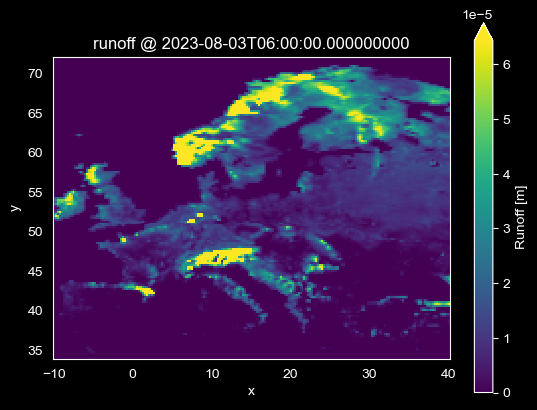

In [38]:
# Koordinaten
y_dim = next(d for d in da_t.dims if d.lower() in {"y","lat","latitude"})
x_dim = next(d for d in da_t.dims if d.lower() in {"x","lon","longitude"})

# Plot map
da_t = da_t.transpose(y_dim, x_dim)  # Ordnung erzwingen
da_t.plot.pcolormesh(x=x_dim, y=y_dim, cmap="viridis", robust=True)
plt.title(f"{'runoff'} @ {da_t[time_dim].values}")
plt.gca().set_aspect("equal")
plt.show()